# UdaciSense: Optimized Object Recognition

## Notebook 3: Multi-step Optimization Pipeline

 
In this notebook, you'll implement the multi-step optimization pipeline based on the findings from the previous experiments. The goal is to combine different optimization techniques to meet all requirements:

- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You may need to experiment with different pipelines as you try to hit your targets. Make sure to start with those that are easier to implement!

### Overview: Implementation Plan

**TODO**: *Add your implementation plan here*

### Step 1: Set up the environment

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

In [2]:
# Import necessary libraries
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import sys
sys.path.append('..')
from model_compression.post_training.pruning import prune_model
from model_compression.post_training.quantization import quantize_model
from model_compression.post_training.graph_optimization import optimize_model, verify_model_equivalence
from model_compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from model_compression.in_training.pruning import train_with_pruning
from model_compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,  # For experimentation
    is_quantized  # For quantization
)

In [3]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

In [4]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (NVIDIA GeForce RTX 3070 Laptop GPU)']


In [5]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Extracting household classes from CIFAR100 for test set...
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


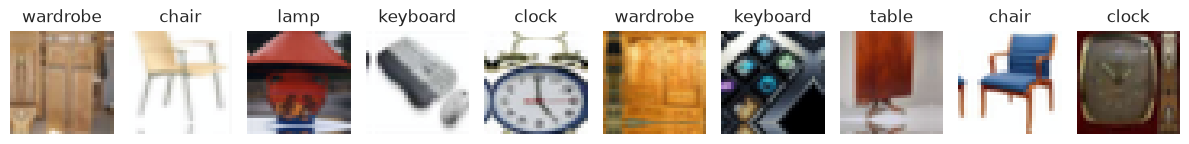


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


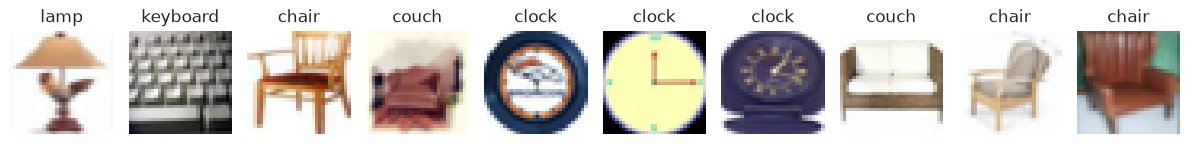

In [6]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3: Load the baseline model and metrics

In [7]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))
print_model_summary(baseline_model)

# Load baseline metrics
with open(f"../results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activati

### Step 4: Implement and evaluate optimization pipelines

Based on your analysis in the previous notebook, you'll implement and evaluate different multi-step pipelines to find the optimal approach for meeting all requirements.

In [8]:
# NOTE: Feel free to change the class entirely, or to move to a function if preferred
class OptimizationPipeline:
    def __init__(self, name, baseline_model, train_loader, test_loader, class_names, input_size):
        """
        Initialize the optimization pipeline.
        
        Args:
            name: Name of the pipeline for tracking and saving
            baseline_model: The baseline model to optimize
            train_loader: DataLoader for training data (needed for some optimization techniques)
            test_loader: DataLoader for testing data (needed for evaluation)
            class_names: List of class names in the dataset
            input_size: Input tensor size
        """
        self.name = name
        self.baseline_model = baseline_model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.class_names = class_names
        self.input_size = input_size
        self.optimized_model = None
        self.steps = []
        self.results = {}
        
        # Create directories for this pipeline
        self.model_dir = f"../models/pipeline/{name}"
        self.checkpoint_dir = f"{self.model_dir}/checkpoints"
        self.results_dir = f"../results/pipeline/{name}"
        
        for d in [self.model_dir, self.checkpoint_dir, self.results_dir]:
            os.makedirs(d, exist_ok=True)
    
    def add_step(self, step_name, step_function, **kwargs):
        """
        Add an optimization step to the pipeline.
        
        Args:
            step_name: Name of the step
            step_function: Function that implements the step
            **kwargs: Arguments to pass to the step function
        """
        self.steps.append({
            'name': step_name,
            'function': step_function,
            'args': kwargs
        })
        return self
    
    def run(self, device=torch.device('cpu'), file_extension='pth'):
        """
        Run the optimization pipeline.
        
        Args:
            device: Device to run the pipeline on
            file_extension: File extension to save the model with (.pt for torchscript, else .pth)
            
        Returns:
            The optimized model
        """
        print(f"\n{'='*50}")
        print(f"Running pipeline: {self.name}")
        print(f"{'='*50}\n")
        
        # Start with the baseline model
        current_model = self.baseline_model
        
        # Save intermediate results after each step
        step_results = []
        
        # Run the pipeline iteratively
        # For each stage in the pipeline:
        # 1. Apply the specified technique with the given parameters
        # 2. Evaluate the model after applying the technique
        # 3. Store the results for later comparison
        for i, step in enumerate(self.steps):
            print(f"\n{'-'*50}")
            print(f"Step {i+1}: {step['name']}")
            print(f"{'-'*50}\n")

            step_name = step['name']
            step_function = step['function']
            step_args = step['args']

            # 1. Apply this step's optimization technique to the model
            #    produced by the previous step (chaining techniques
            #    together, e.g. prune -> quantize -> graph-optimize).
            current_model = step_function(current_model, **step_args)

            # Give each step's intermediate checkpoint a unique, readable
            # name so the pipeline's progression can be inspected/reloaded
            # later if needed.
            safe_step_name = step_name.replace(' ', '_').lower()
            step_checkpoint_path = (
                f"{self.checkpoint_dir}/step_{i+1}_{safe_step_name}.{file_extension}"
            )

            # TorchScript modules can't be saved with the regular
            # state-dict-based save_model helper -- they need torch.jit.save.
            if isinstance(current_model, torch.jit.ScriptModule):
                torch.jit.save(current_model, step_checkpoint_path)
            else:
                save_model(current_model, step_checkpoint_path)

            # 2. Evaluate the model as it stands after this step.
            step_metrics, step_confusion_matrix = evaluate_optimized_model(
                current_model,
                self.test_loader,
                f"{self.name}/step_{i+1}_{safe_step_name}",
                self.class_names,
                self.input_size,
                device=device,
            )

            # 3. Store this step's results for later comparison/plotting.
            step_results.append({
                'step_name': step_name,
                'args': {k: str(v) for k, v in step_args.items()},
                'metrics': step_metrics,
            })

            print(
                f"After '{step_name}': "
                f"Top-1 Acc={step_metrics['accuracy']['top1_acc']:.2f}%, "
                f"Size={step_metrics['size']['model_size_mb']:.2f} MB"
            )
        
        self.optimized_model = current_model
        final_path = f"{self.model_dir}/model.{file_extension}"
        
        # Save final model
        # Remember that different pytorch model format will require different saving mechanisms
        if isinstance(self.optimized_model, torch.jit.ScriptModule):
            torch.jit.save(self.optimized_model, final_path)
        else:
            save_model(self.optimized_model, final_path)

        # Compute final metrics and comparison against the untouched baseline.
        final_metrics, final_confusion_matrix = evaluate_optimized_model(
            self.optimized_model,
            self.test_loader,
            self.name,
            self.class_names,
            self.input_size,
            device=device,
        )

        final_comparison = compare_optimized_model_to_baseline(
            self.baseline_model,
            self.optimized_model,
            self.name,
            self.test_loader,
            self.class_names,
            device=device,
        )
        
        # Save pipeline results
        self.results = {
            'pipeline_name': self.name,
            'steps': step_results,
            'final_metrics': final_metrics,  # As returned by evaluate_optimized_model()
            'final_comparison': final_comparison  # As returned by compare_optimized_model_to_baseline()
        }
        
        with open(f"{self.results_dir}/pipeline_metrics.json", 'w') as f:
            json.dump(self.results, f, indent=4)
        
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} completed")
        print(f"{'='*50}\n")
        
        return self.optimized_model
    
    def visualize_results(self, baseline_metrics=baseline_metrics, device=torch.device('cpu')):
        """
        Visualize the results of the pipeline.

        Args:
            baseline_metrics: Dictionary of baseline metrics for comparison.
            device: Device to run the pipeline on

        """
        if not self.results:
            print("No results to visualize. Please run the pipeline first.")
            return

        # Define device name
        device_name = 'cpu' if device==torch.device('cpu') else 'cuda'

        # Extract metrics from each step
        step_names = [step['step_name'] for step in self.results['steps']]
        model_sizes = [step['metrics']['size']['model_size_mb'] for step in self.results['steps']]
        model_memory_sizes = [step['metrics']['size']['total_params'] for step in self.results['steps']]
        times = [step['metrics']['timing'][device_name]['avg_time_ms'] for step in self.results['steps']]
        accuracies = [step['metrics']['accuracy']['top1_acc'] for step in self.results['steps']]

        # Add baseline metrics
        step_names.insert(0, 'Baseline')
        baseline_size = baseline_metrics['size']['model_size_mb']
        baseline_memory_size = baseline_metrics['size']['total_params']
        baseline_inference_time = baseline_metrics['timing'][device_name]['avg_time_ms']
        baseline_accuracy = baseline_metrics['accuracy']['top1_acc']

        model_sizes.insert(0, baseline_size)
        model_memory_sizes.insert(0, baseline_memory_size)
        times.insert(0, baseline_inference_time)
        accuracies.insert(0, baseline_accuracy)

        # Create figure with subplots
        fig, axes = plt.subplots(4, 1, figsize=(12, 15))

        # Plot model size
        axes[0].bar(step_names, model_sizes, color='blue')
        axes[0].set_title('Model Size (MB)')
        axes[0].set_ylabel('Size (MB)')
        axes[0].axhline(y=baseline_size * (1-TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[0].legend()
        for i, v in enumerate(model_sizes):
            axes[0].text(i, v + 0.1, f"{v:.2f}", ha='center')

        axes[1].bar(step_names, model_memory_sizes, color='blue')
        axes[1].set_title('Model Size (# Parameters)')
        axes[1].set_ylabel('Peak Memory')
        axes[1].axhline(y=baseline_memory_size * (1-TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[1].legend()
        for i, v in enumerate(model_memory_sizes):
            axes[1].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot inference time
        axes[2].bar(step_names, times, color='green')
        axes[2].set_title('Inference Time (ms)')
        axes[2].set_ylabel('Time (ms)')
        axes[2].axhline(y=baseline_inference_time * (1-TARGET_INFERENCE_SPEEDUP), color='r', linestyle='--', label=f"Target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        axes[2].legend()
        for i, v in enumerate(times):
            axes[2].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot accuracy
        axes[3].bar(step_names, accuracies, color='purple')
        axes[3].set_title('Top-1 Accuracy (%)')
        axes[3].set_ylabel('Accuracy (%)')
        axes[3].axhline(y=baseline_accuracy * (1-MAX_ALLOWED_ACCURACY_DROP), color='r', linestyle='--', label=f"Minimum acceptable ({MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        axes[3].legend()
        for i, v in enumerate(accuracies):
            axes[3].text(i, v + 0.5, f"{v:.2f}%", ha='center')

        plt.tight_layout()
        plt.savefig(f"{self.results_dir}/pipeline_visualization.png")
        plt.show()

        # Print final results summary
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} Results Summary")
        print(f"{'='*50}")

        # Size comparison
        size_reduction = (baseline_size - model_sizes[-1]) / baseline_size * 100
        print(f"\nModel Size (MB):")
        print(f"  Baseline: {baseline_size:.2f} MB")
        print(f"  Final: {model_sizes[-1]:.2f} MB")
        print(f"  Reduction: {size_reduction:.2f}%")
        target_size = baseline_size * (1-TARGET_MODEL_COMPRESSION)
        if model_sizes[-1] <= target_size:
            print(f"  ✅ Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_size:.2f} MB)")

        memory_size_reduction = (baseline_memory_size - model_memory_sizes[-1]) / baseline_memory_size * 100
        print(f"\nModel Size (# Parameters):")
        print(f"  Baseline: {baseline_memory_size:.2f} MB")
        print(f"  Final: {model_memory_sizes[-1]:.2f} MB")
        print(f"  Reduction: {memory_size_reduction:.2f}%")
        target_memory_size = baseline_memory_size * (1-TARGET_MODEL_COMPRESSION)
        if model_memory_sizes[-1] <= target_memory_size:
            print(f"  ✅ Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_memory_size:.2f} MB)")


        # Inference time comparison
        time_reduction = (baseline_inference_time - times[-1]) / baseline_inference_time * 100
        print(f"\nInference Time (CPU):")
        print(f"  Baseline: {baseline_inference_time:.2f} ms")
        print(f"  Final: {times[-1]:.2f} ms")
        print(f"  Reduction: {time_reduction:.2f}%")
        target_time = baseline_inference_time * (1-TARGET_INFERENCE_SPEEDUP)
        if times[-1] <= target_time:
            print(f"  ✅ Meets target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_time:.2f} ms)")

        # Accuracy comparison
        accuracy_change = (accuracies[-1] - baseline_accuracy) / baseline_accuracy * 100
        print(f"\nAccuracy:")
        print(f"  Baseline: {baseline_accuracy:.2f}%")
        print(f"  Final: {accuracies[-1]:.2f}%")
        print(f"  Change: {accuracy_change:.2f}%")
        min_acceptable = baseline_accuracy * (1-MAX_ALLOWED_ACCURACY_DROP)
        if accuracies[-1] >= min_acceptable:
            print(f"  ✅ Meets target (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        else:
            print(f"  ❌ Does not meet target (Goal: ≥{min_acceptable:.2f}%)")

        # Overall assessment
        print(f"\nOverall Assessment:")
        if model_sizes[-1] <= target_size and times[-1] <= target_time and accuracies[-1] >= min_acceptable:
            print(f"  ✅ Pipeline meets all requirements")
        else:
            print(f"  ❌ Pipeline does not meet all requirements")

In [9]:
def apply_post_training_pruning(model, pruning_method="l1_unstructured", amount=0.3,
                                 modules_to_prune=None, custom_pruning_fn=None,
                                 n=None, dim=None):
    """Pipeline step: apply one-shot post-training pruning to `model`."""
    return prune_model(
        model,
        pruning_method=pruning_method,
        amount=amount,
        modules_to_prune=modules_to_prune,
        custom_pruning_fn=custom_pruning_fn,
        n=n,
        dim=dim,
    )


def apply_dynamic_quantization(model, backend="fbgemm"):
    """Pipeline step: apply post-training dynamic quantization to `model`."""
    return quantize_model(
        model,
        quantization_type="dynamic",
        backend=backend,
    )


def apply_graph_optimization(model, optimization_method="torchscript",
                              input_shape=(1, 3, 224, 224), device=torch.device('cpu'),
                              custom_options=None):
    """Pipeline step: apply TorchScript/FX graph optimization to `model`."""
    return optimize_model(
        model,
        optimization_method=optimization_method,
        input_shape=input_shape,
        device=device,
        custom_options=custom_options,
    )


def apply_knowledge_distillation(model, teacher_model=None, training_config=None,
                                  checkpoint_path="checkpoints/pipeline_distilled_model.pth"):
    """
    Pipeline step: train `model` (the student) via knowledge distillation
    from `teacher_model`.

    Note: unlike the other steps, this one effectively replaces the
    incoming model's weights via training rather than transforming it
    directly -- `model` should be a freshly constructed student
    architecture (e.g. MobileNetV3_Household_Small), since distillation
    trains it largely from scratch.
    """
    if teacher_model is None:
        raise ValueError("apply_knowledge_distillation requires a `teacher_model` kwarg")
    if training_config is None:
        raise ValueError("apply_knowledge_distillation requires a `training_config` kwarg")

    distilled_model, _, _, _ = train_with_distillation(
        student_model=model,
        teacher_model=teacher_model,
        train_loader=train_loader,
        test_loader=test_loader,
        training_config=training_config,
        checkpoint_path=checkpoint_path,
    )
    return distilled_model


def apply_in_training_pruning(model, training_config=None,
                               checkpoint_path="checkpoints/pipeline_pruned_model.pth"):
    """Pipeline step: fine-tune `model` with gradual magnitude pruning."""
    if training_config is None:
        raise ValueError("apply_in_training_pruning requires a `training_config` kwarg")

    pruned_model, _, _, _ = train_with_pruning(
        model,
        train_loader,
        test_loader,
        training_config,
        checkpoint_path=checkpoint_path,
    )
    return pruned_model


def apply_in_training_quantization(model, training_config=None, backend="fbgemm",
                                    checkpoint_path="checkpoints/pipeline_qat_model.pth"):
    """Pipeline step: fine-tune `model` with quantization-aware training."""
    if training_config is None:
        raise ValueError("apply_in_training_quantization requires a `training_config` kwarg")

    quantized_model, _, _, _ = train_model_qat(
        model,
        train_loader,
        test_loader,
        training_config,
        checkpoint_path=checkpoint_path,
        backend=backend,
    )
    return quantized_model

In [10]:
from torch.quantization.quantize_jit import quantize_dynamic_jit
from torch.quantization import default_dynamic_qconfig

def apply_graph_opt_then_quantize(model, backend='fbgemm'):
    model.eval()
    scripted = torch.jit.script(model)
    scripted.eval()
    frozen = torch.jit.freeze(scripted)
    optimized = torch.jit.optimize_for_inference(frozen)

    torch.backends.quantized.engine = backend
    qconfig_dict = {'': default_dynamic_qconfig}  # '' = apply to whole model
    quantized_jit = quantize_dynamic_jit(optimized, qconfig_dict)
    return quantized_jit

#### Pipelines

Note: You may want to recreate the cell below for new pipelines too, if needed.


Running pipeline: prune_quantize_graphopt_cpu


--------------------------------------------------
Step 1: post_training_pruning
--------------------------------------------------

Pruning 54 modules with method: global_unstructured, amount: 0.4
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 39.90%
Model saved to ../models/pipeline/prune_quantize_graphopt_cpu/checkpoints/step_1_post_training_pruning.pt

Evaluating performance of optimized model...


gpu runs: 100%|██████████| 100/100 [00:00<00:00, 221.59it/s]


Baseline metrics saved at ../results/prune_quantize_graphopt_cpu/step_1_post_training_pruning/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:07<00:00,  1.02it/s]


Confusion matrix saved to ../results/prune_quantize_graphopt_cpu/step_1_post_training_pruning/confusion_matrix.png


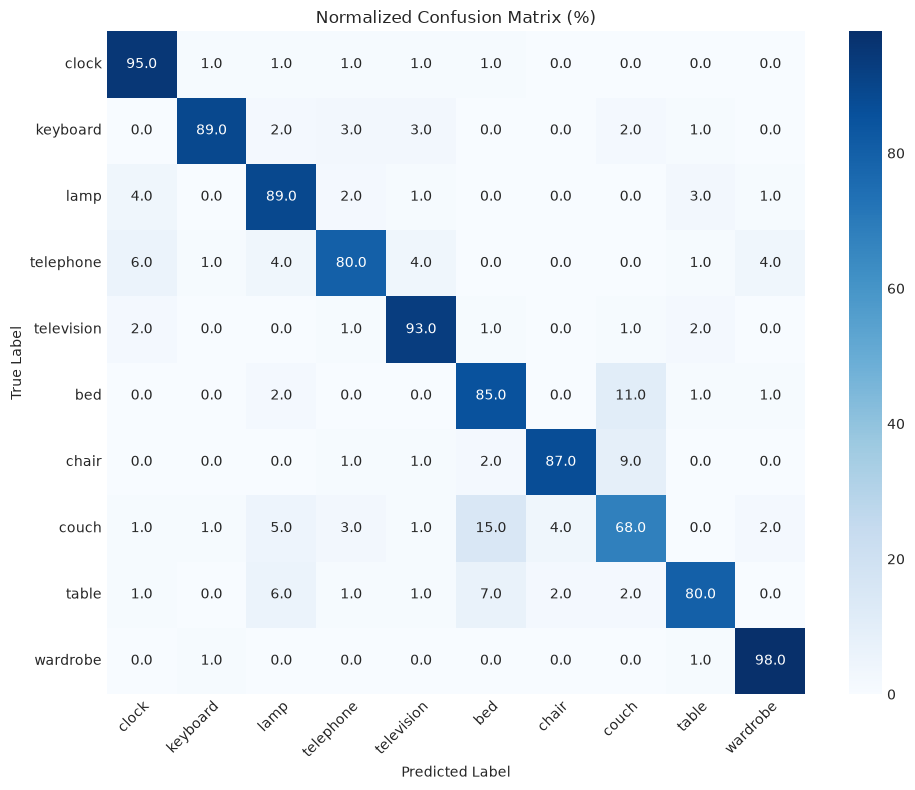


Optimized Model Metrics (prune_quantize_graphopt_cpu/step_1_post_training_pruning):
Accuracy: 86.40%
Model Size: 5.96 MB
CPU Inference Time: 6.34 ms (157.82 FPS)
CUDA Inference Time: 4.53 ms (220.58 FPS)
After 'post_training_pruning': Top-1 Acc=86.40%, Size=5.96 MB

--------------------------------------------------
Step 2: dynamic_quantization
--------------------------------------------------

Applying dynamic quantization...
Model saved to ../models/pipeline/prune_quantize_graphopt_cpu/checkpoints/step_2_dynamic_quantization.pt

Evaluating performance of optimized model...


cpu runs: 100%|██████████| 100/100 [00:00<00:00, 156.62it/s]


Baseline metrics saved at ../results/prune_quantize_graphopt_cpu/step_2_dynamic_quantization/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:07<00:00,  1.09it/s]


Confusion matrix saved to ../results/prune_quantize_graphopt_cpu/step_2_dynamic_quantization/confusion_matrix.png


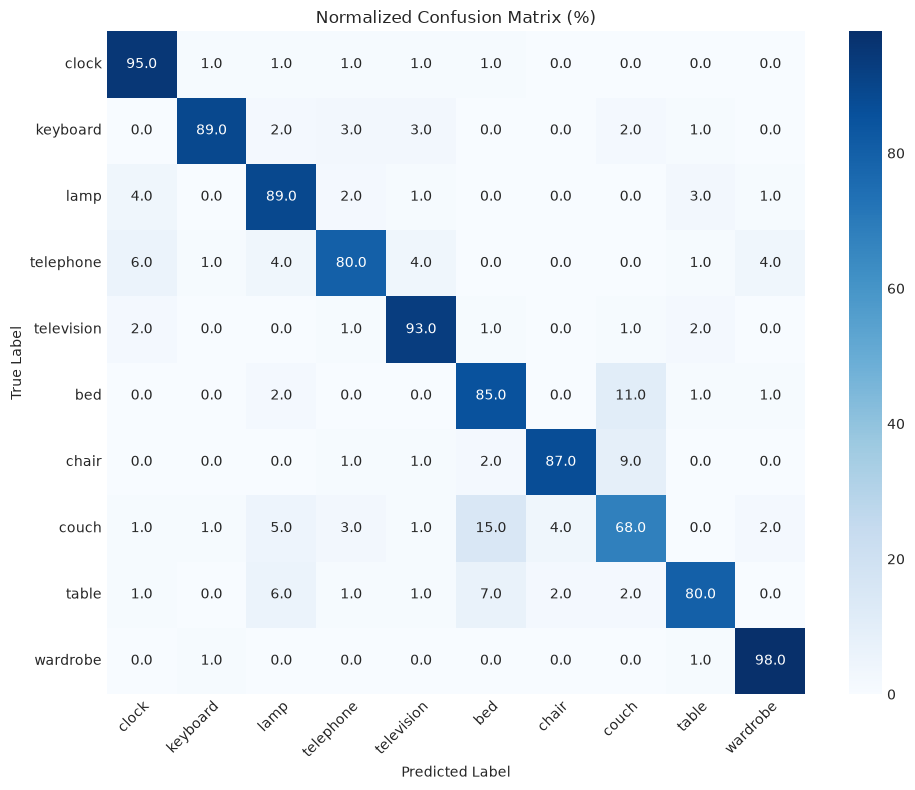


Optimized Model Metrics (prune_quantize_graphopt_cpu/step_2_dynamic_quantization):
Accuracy: 86.40%
Model Size: 4.24 MB
CPU Inference Time: 6.41 ms (156.07 FPS)
After 'dynamic_quantization': Top-1 Acc=86.40%, Size=4.24 MB

--------------------------------------------------
Step 3: graph_optimization
--------------------------------------------------


Evaluating performance of optimized model...


gpu warmup:   0%|          | 0/10 [00:00<?, ?it/s]


Traceback of TorchScript (most recent
Baseline metrics saved at ../results/prune_quantize_graphopt_cpu/step_3_graph_optimization/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:06<00:00,  1.19it/s]


Confusion matrix saved to ../results/prune_quantize_graphopt_cpu/step_3_graph_optimization/confusion_matrix.png


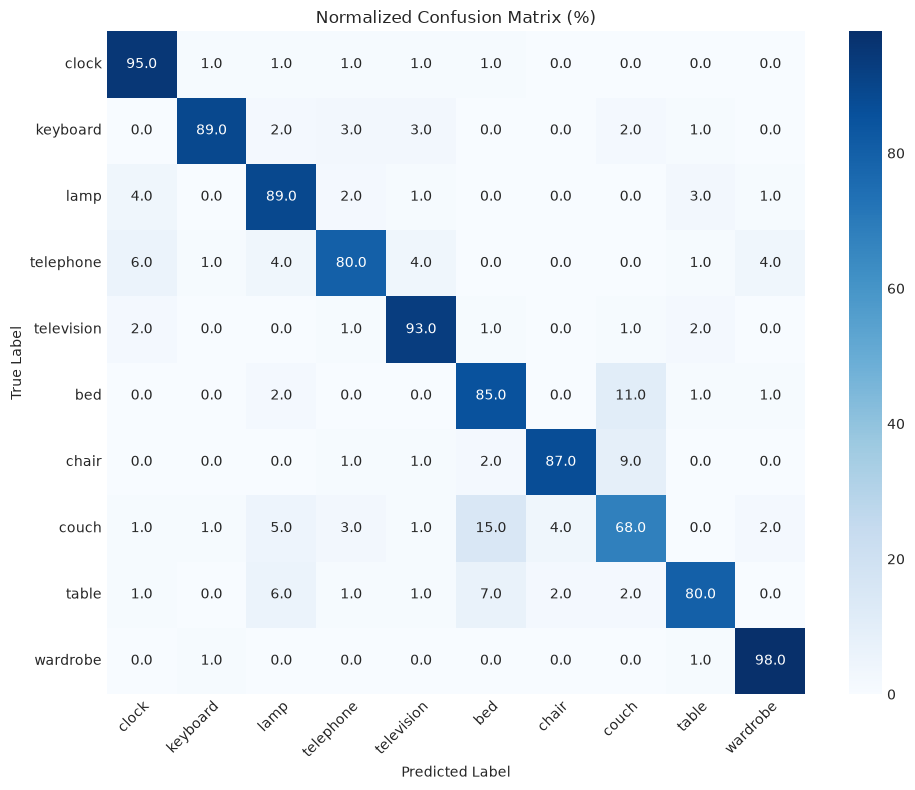


Optimized Model Metrics (prune_quantize_graphopt_cpu/step_3_graph_optimization):
Accuracy: 86.40%
Model Size: 4.13 MB
CPU Inference Time: 3.57 ms (279.77 FPS)
After 'graph_optimization': Top-1 Acc=86.40%, Size=4.13 MB

Evaluating performance of optimized model...


gpu warmup:   0%|          | 0/10 [00:00<?, ?it/s]


Traceback of TorchScript (most recent
Baseline metrics saved at ../results/prune_quantize_graphopt_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:05<00:00,  1.57it/s]


Confusion matrix saved to ../results/prune_quantize_graphopt_cpu/confusion_matrix.png


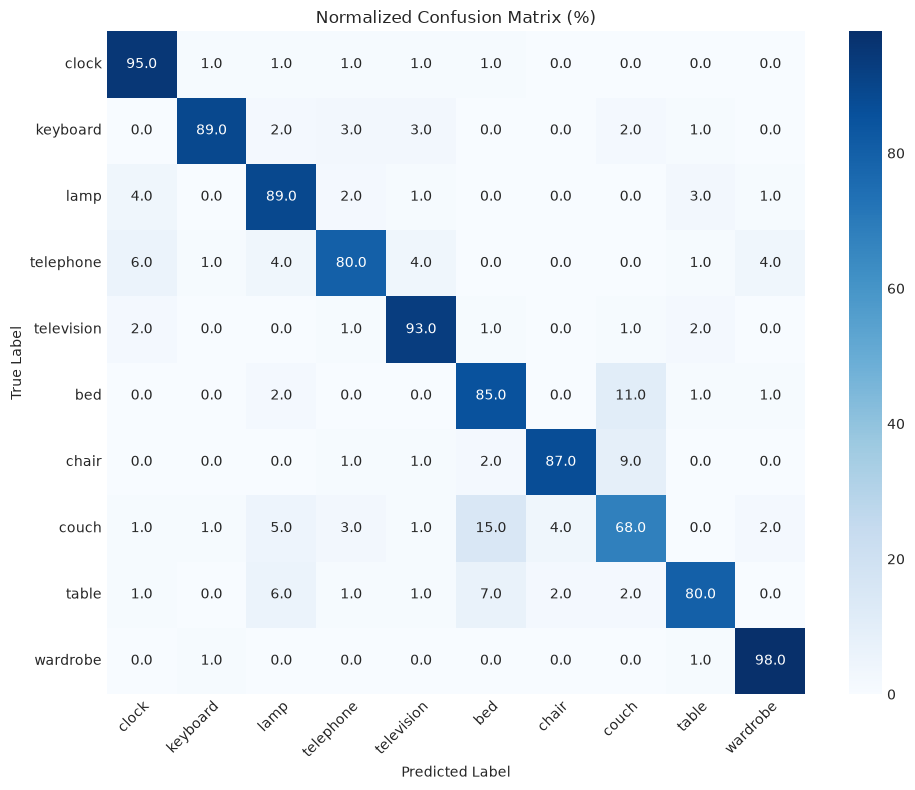


Optimized Model Metrics (prune_quantize_graphopt_cpu):
Accuracy: 86.40%
Model Size: 4.13 MB
CPU Inference Time: 3.94 ms (253.83 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


gpu runs: 100%|██████████| 100/100 [00:00<00:00, 198.03it/s]


Get metrics of optimized model...


gpu warmup:   0%|          | 0/10 [00:00<?, ?it/s]


Traceback of TorchScript (most recent
Model comparison plot saved to ../results/prune_quantize_graphopt_cpu/comparison.png


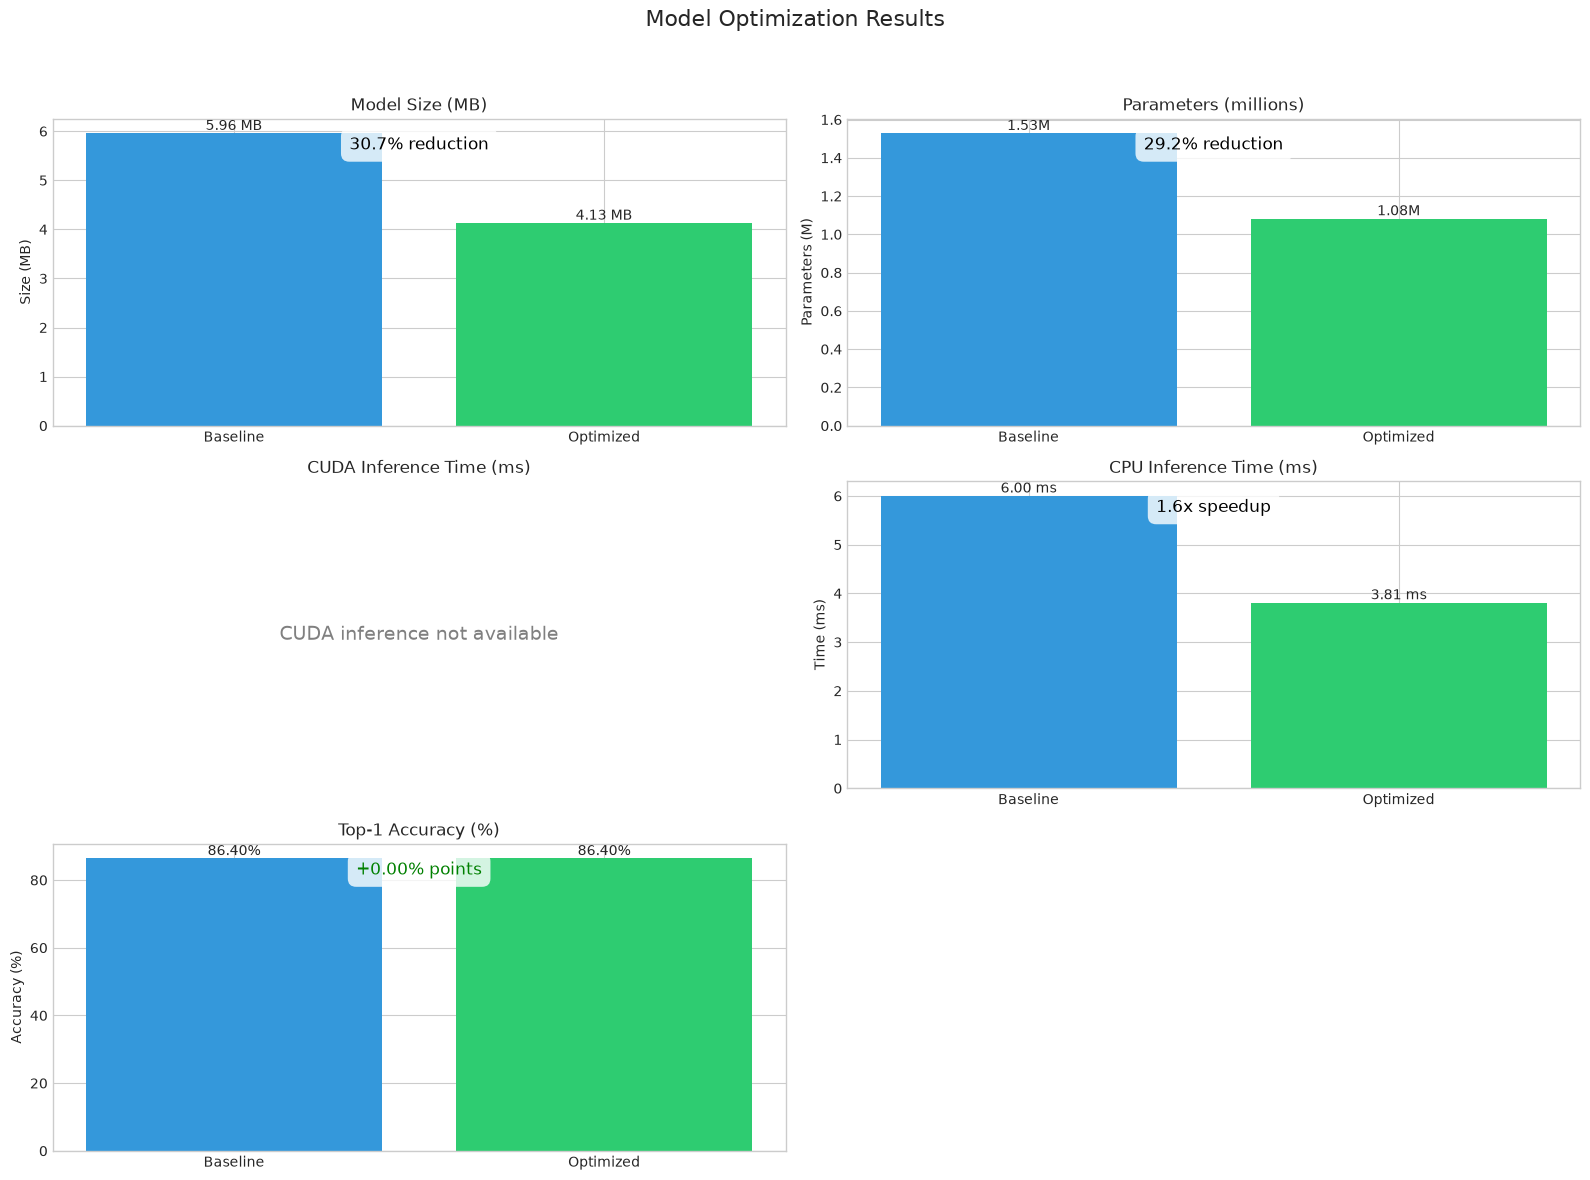


prune_quantize_graphopt_cpu Results:
Model Size: 4.13 MB (30.7% reduction)
Parameters: 1,082,549 (29.2% reduction)
CPU Inference Time: 3.81 ms (1.6x speedup)
Accuracy: 86.40% (+0.00% change)
Requirements met: False

Pipeline prune_quantize_graphopt_cpu completed



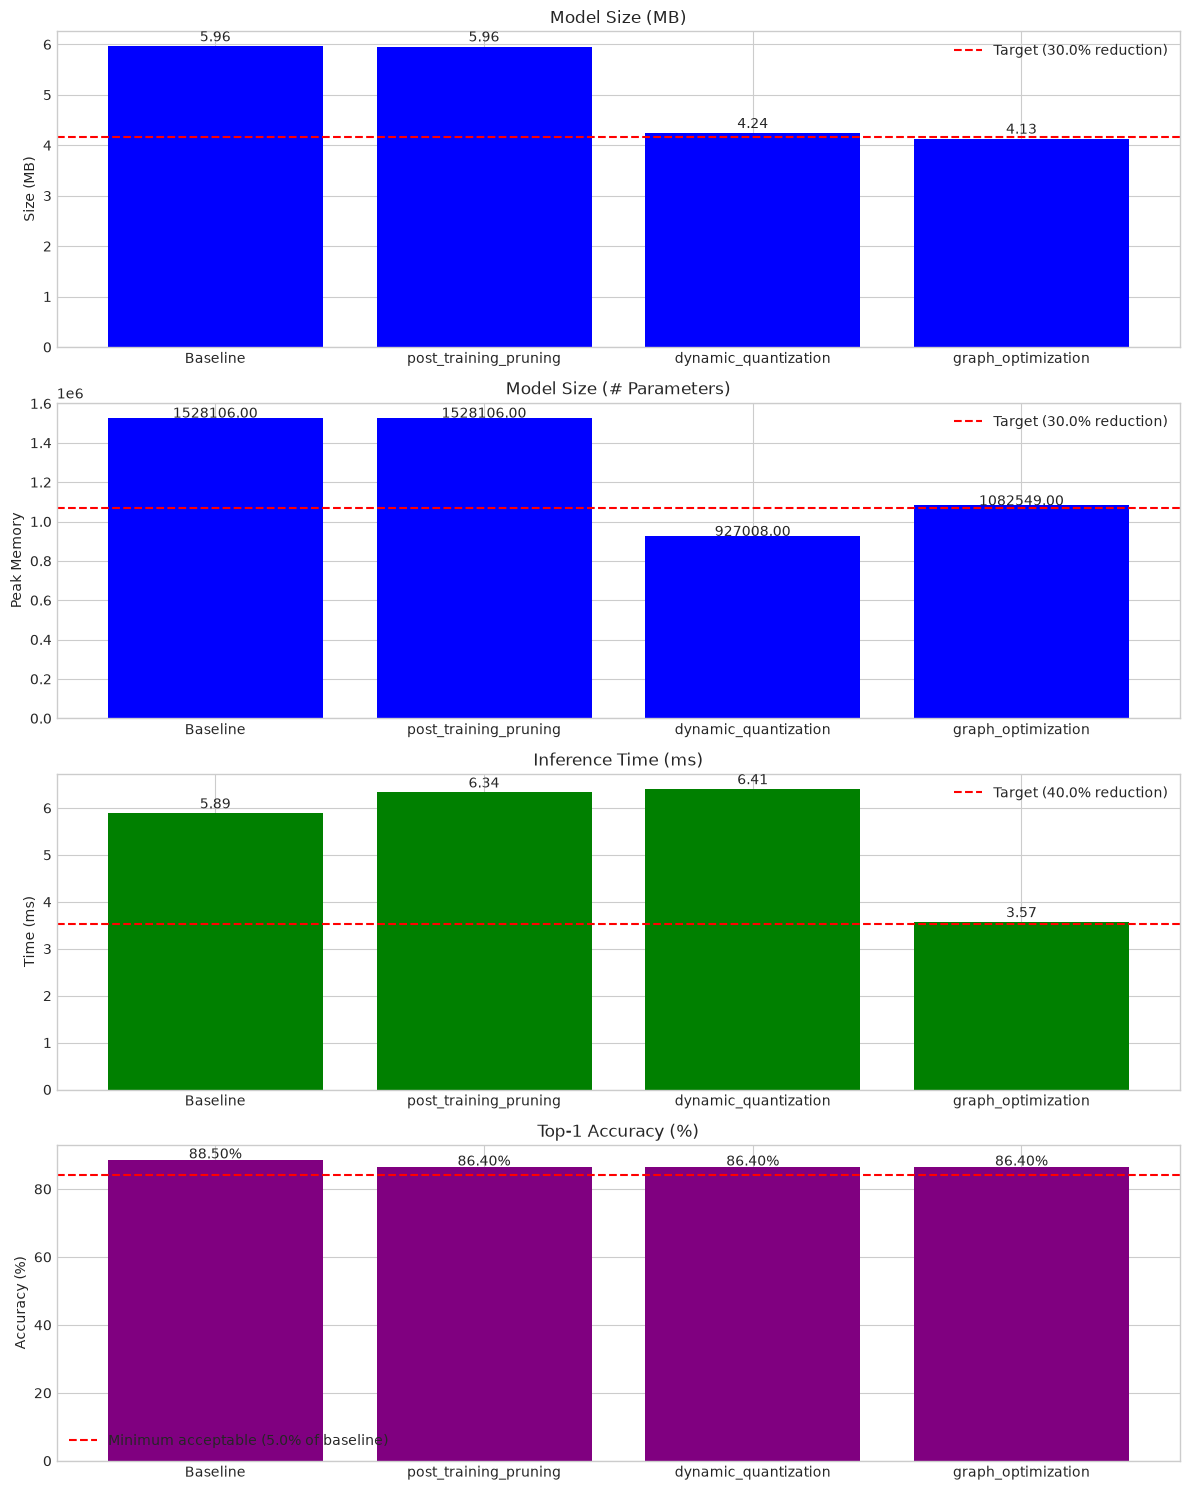


Pipeline prune_quantize_graphopt_cpu Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 4.13 MB
  Reduction: 30.71%
  ✅ Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 1082549.00 MB
  Reduction: 29.16%
  ❌ Does not meet target (Goal: 1069674.20 MB)

Inference Time (CPU):
  Baseline: 5.89 ms
  Final: 3.57 ms
  Reduction: 39.33%
  ❌ Does not meet target (Goal: 3.54 ms)

Accuracy:
  Baseline: 88.50%
  Final: 86.40%
  Change: -2.37%
  ✅ Meets target (within 5.0% of baseline)

Overall Assessment:
  ❌ Pipeline does not meet all requirements


In [14]:
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))

# Create and run Pipeline #1

# Choose a meaningful and unique pipeline name 
pipeline_name = "prune_quantize_graphopt_cpu"

# Initialize the pipeline
pipeline1 = OptimizationPipeline(
    name=pipeline_name,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size
)

# Add optimization steps using the add_step() function
# Chain: post-training pruning -> dynamic quantization -> TorchScript graph optimization
pipeline1.add_step(
    "post_training_pruning",
    apply_post_training_pruning,
    pruning_method="global_unstructured",
    amount=0.4,
)
pipeline1.add_step(
    "dynamic_quantization",
    apply_dynamic_quantization,
    backend="fbgemm",
)
pipeline1.add_step(
    "graph_optimization",
    apply_graph_optimization,
    optimization_method="torchscript",
    input_shape=input_size,
    device=torch.device('cpu'),
    custom_options={"use_script": True, "optimize_for_inference": False},
)

# Run the pipeline
optimized_model_p1 = pipeline1.run(device=torch.device('cpu'), file_extension='pt')

# Visualize the results
# Choose the device to report performance for
device = torch.device('cpu')  # Define as torch.device()
pipeline1.visualize_results(baseline_metrics, device)


Running pipeline: prune_graphopt_quantize_cpu


--------------------------------------------------
Step 1: post_training_pruning
--------------------------------------------------

Pruning 54 modules with method: global_unstructured, amount: 0.4
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 39.90%
Model saved to ../models/pipeline/prune_graphopt_quantize_cpu/checkpoints/step_1_post_training_pruning.pt

Evaluating performance of optimized model...


gpu runs: 100%|██████████| 100/100 [00:00<00:00, 180.93it/s]


Baseline metrics saved at ../results/prune_graphopt_quantize_cpu/step_1_post_training_pruning/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:07<00:00,  1.07it/s]


Confusion matrix saved to ../results/prune_graphopt_quantize_cpu/step_1_post_training_pruning/confusion_matrix.png


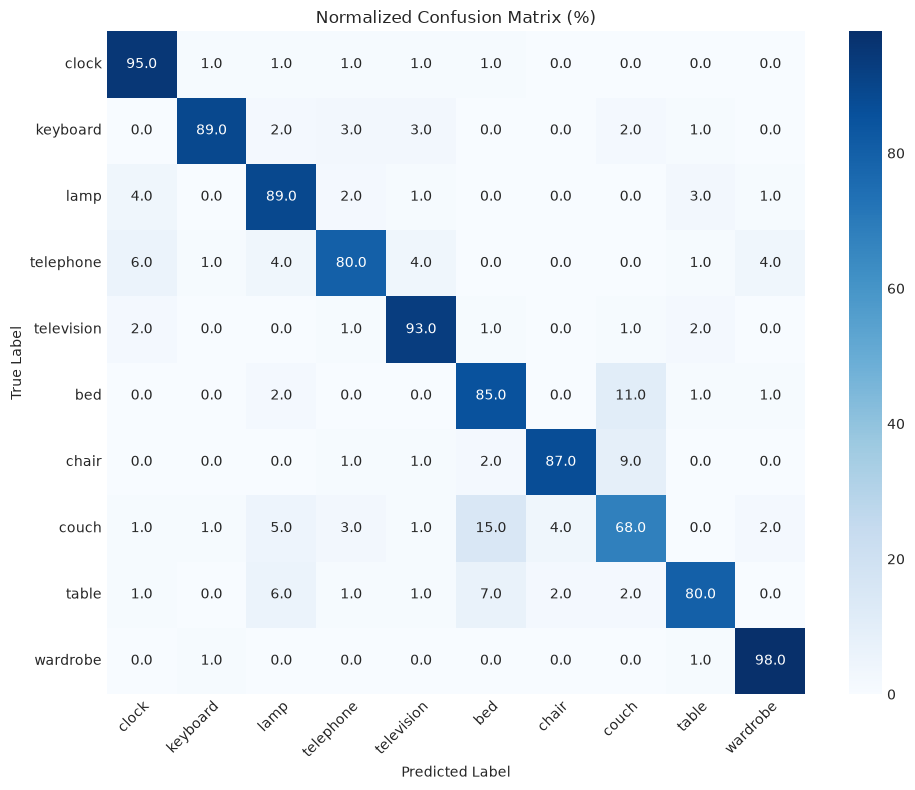


Optimized Model Metrics (prune_graphopt_quantize_cpu/step_1_post_training_pruning):
Accuracy: 86.40%
Model Size: 5.96 MB
CPU Inference Time: 6.25 ms (159.99 FPS)
CUDA Inference Time: 5.55 ms (180.31 FPS)
After 'post_training_pruning': Top-1 Acc=86.40%, Size=5.96 MB

--------------------------------------------------
Step 2: graphopt_dynamic_quantization
--------------------------------------------------


Evaluating performance of optimized model...


gpu warmup:   0%|          | 0/10 [00:00<?, ?it/s]


Traceback of TorchScript (most recent
Baseline metrics saved at ../results/prune_graphopt_quantize_cpu/step_2_graphopt_dynamic_quantization/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:06<00:00,  1.31it/s]


Confusion matrix saved to ../results/prune_graphopt_quantize_cpu/step_2_graphopt_dynamic_quantization/confusion_matrix.png


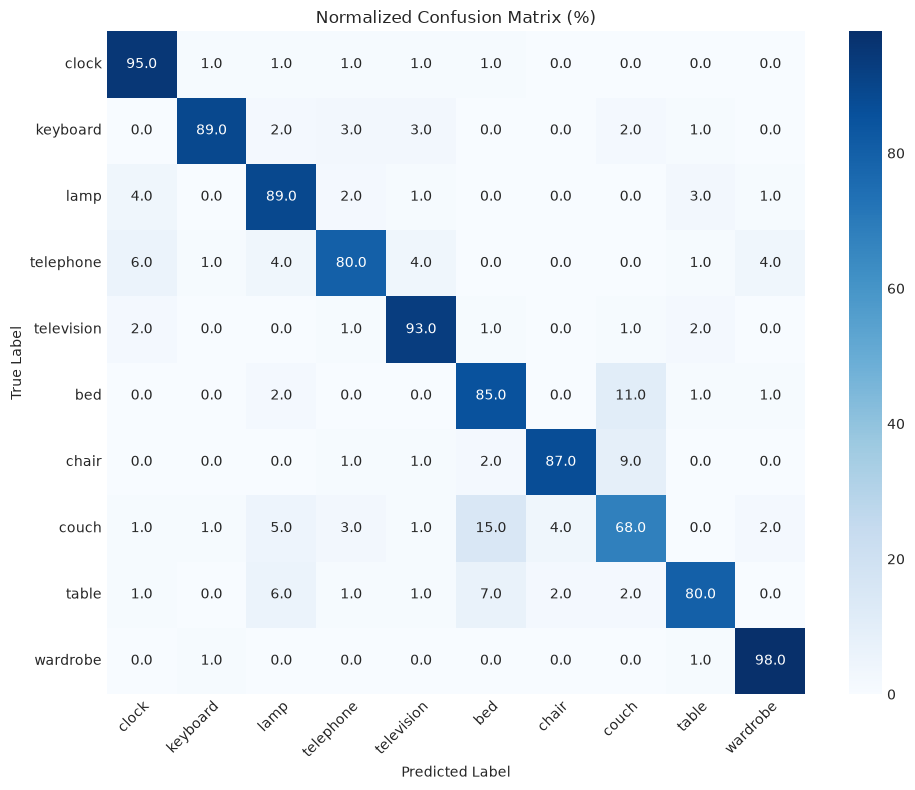


Optimized Model Metrics (prune_graphopt_quantize_cpu/step_2_graphopt_dynamic_quantization):
Accuracy: 86.40%
Model Size: 2.31 MB
CPU Inference Time: 6.04 ms (165.47 FPS)
After 'graphopt_dynamic_quantization': Top-1 Acc=86.40%, Size=2.31 MB

Evaluating performance of optimized model...


gpu warmup:   0%|          | 0/10 [00:00<?, ?it/s]


Traceback of TorchScript (most recent
Baseline metrics saved at ../results/prune_graphopt_quantize_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:06<00:00,  1.31it/s]


Confusion matrix saved to ../results/prune_graphopt_quantize_cpu/confusion_matrix.png


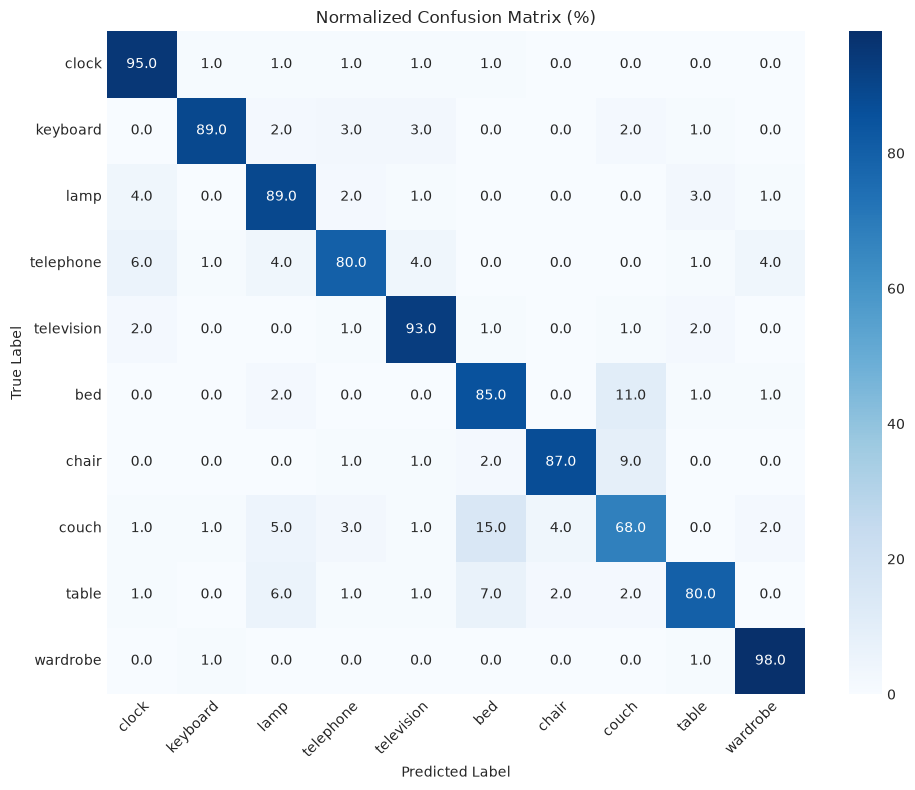


Optimized Model Metrics (prune_graphopt_quantize_cpu):
Accuracy: 86.40%
Model Size: 2.31 MB
CPU Inference Time: 6.60 ms (151.53 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


gpu runs: 100%|██████████| 100/100 [00:00<00:00, 194.20it/s]


Get metrics of optimized model...


gpu warmup:   0%|          | 0/10 [00:00<?, ?it/s]


Traceback of TorchScript (most recent
Model comparison plot saved to ../results/prune_graphopt_quantize_cpu/comparison.png


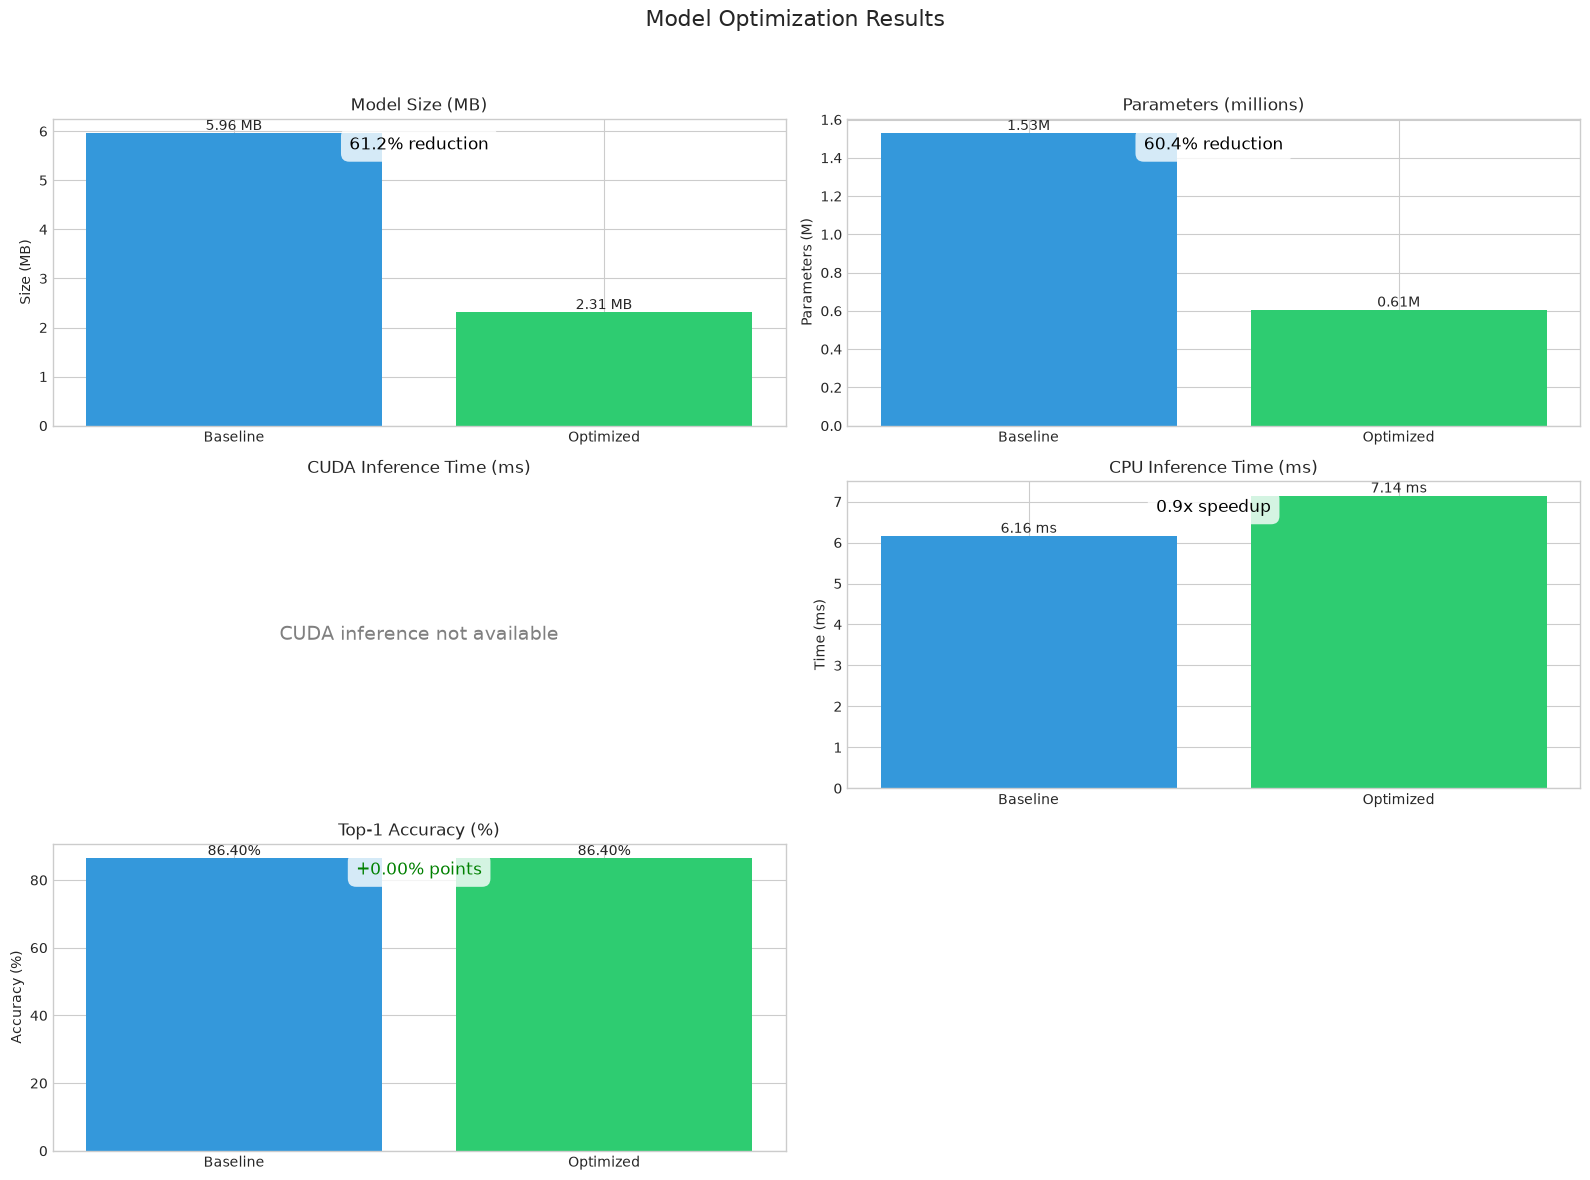


prune_graphopt_quantize_cpu Results:
Model Size: 2.31 MB (61.2% reduction)
Parameters: 605,264 (60.4% reduction)
CPU Inference Time: 7.14 ms (0.9x speedup)
Accuracy: 86.40% (+0.00% change)
Requirements met: False

Pipeline prune_graphopt_quantize_cpu completed



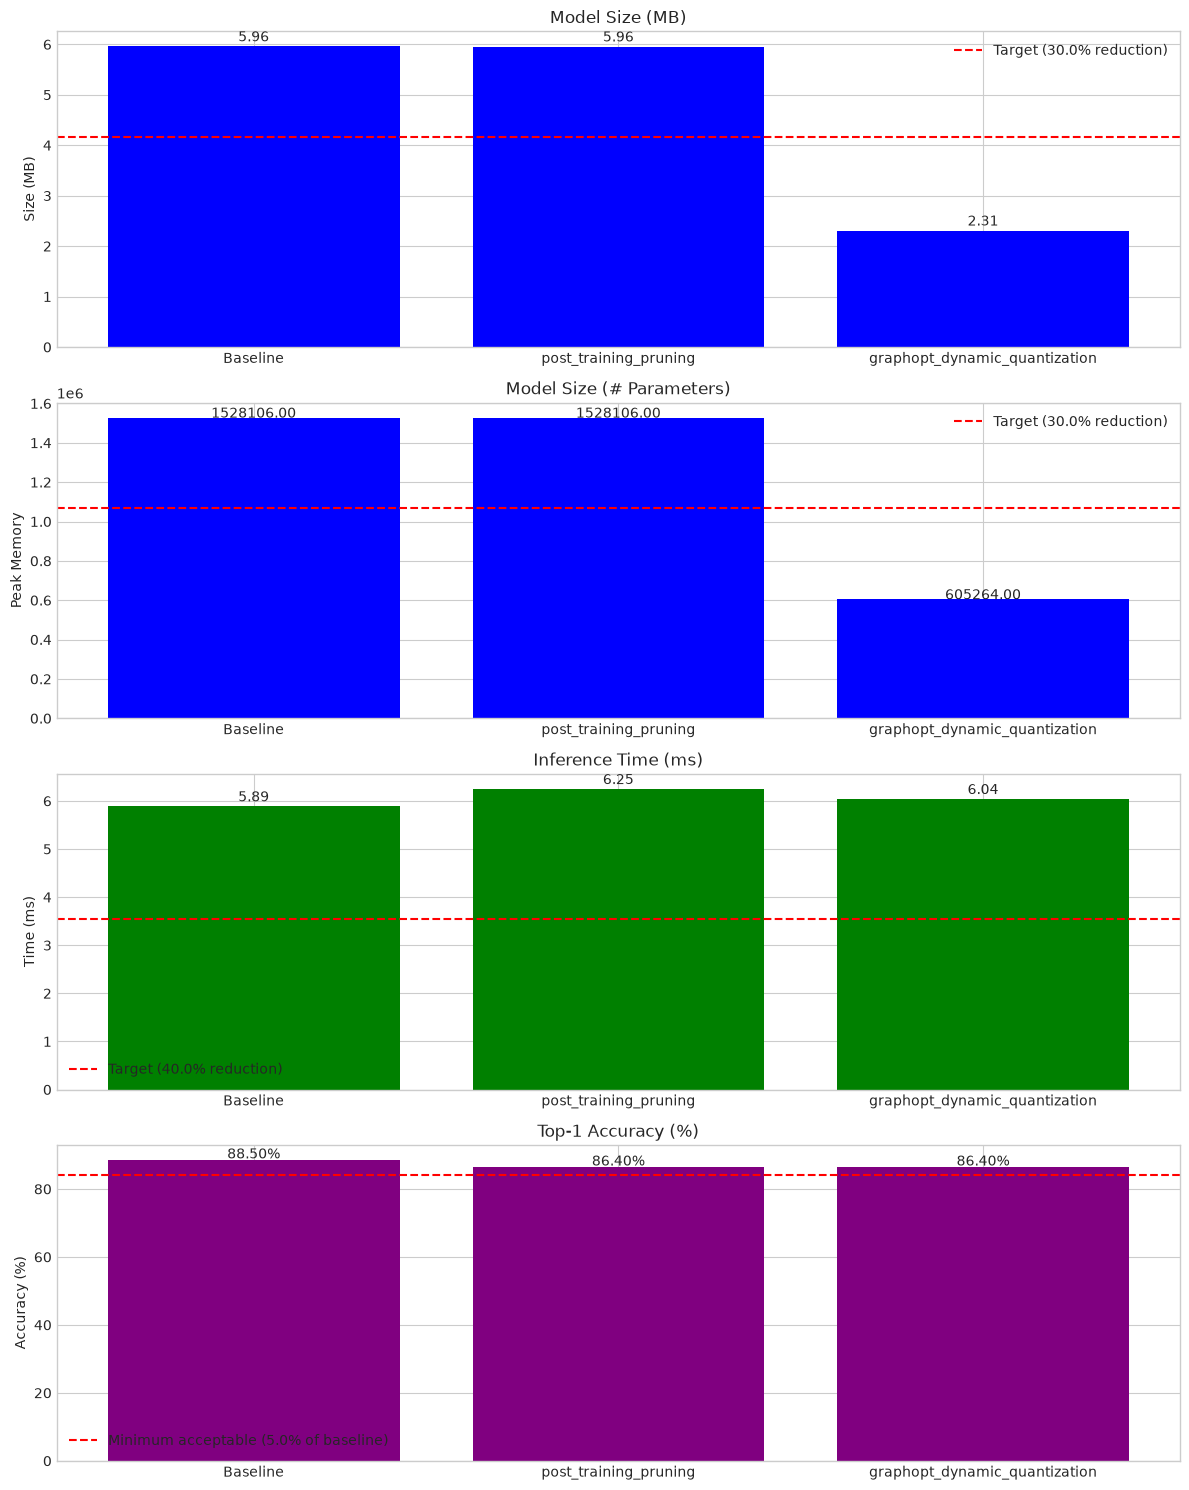


Pipeline prune_graphopt_quantize_cpu Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 2.31 MB
  Reduction: 61.26%
  ✅ Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 605264.00 MB
  Reduction: 60.39%
  ✅ Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 5.89 ms
  Final: 6.04 ms
  Reduction: -2.57%
  ❌ Does not meet target (Goal: 3.54 ms)

Accuracy:
  Baseline: 88.50%
  Final: 86.40%
  Change: -2.37%
  ✅ Meets target (within 5.0% of baseline)

Overall Assessment:
  ❌ Pipeline does not meet all requirements


In [12]:
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))

# Create and run Pipeline #2

# Choose a meaningful and unique pipeline name 
pipeline_name = "prune_graphopt_quantize_cpu"

# Initialize the pipeline
pipeline2 = OptimizationPipeline(
    name=pipeline_name,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size
)

# Add optimization steps using the add_step() function
# Chain: post-training pruning -> dynamic quantization -> TorchScript graph optimization
pipeline2.add_step(
    "post_training_pruning",
    apply_post_training_pruning,
    pruning_method="global_unstructured",
    amount=0.4,
)

pipeline2.add_step(
    "graphopt_dynamic_quantization",
    apply_graph_opt_then_quantize,
    backend="fbgemm",
)


# Run the pipeline
optimized_model_p2 = pipeline2.run(device=torch.device('cpu'), file_extension='pt')

# Visualize the results
# Choose the device to report performance for
device = torch.device('cpu')  # Define as torch.device()
pipeline2.visualize_results(baseline_metrics, device)

### Step 5: Compare All Pipelines

Let's compare the results of all pipelines to determine which one best meets our requirements.

Note that, for simplicity, we re-use the `compare_experiments()` function which will return each step of each pipeline and not final pipeline results all-together.

In [13]:
# Compare all implemented pipelines
pipeline_experiments = [os.path.join('pipeline', exp_name) for exp_name in list_experiments("../results/pipeline/")]

if pipeline_experiments:
    _ = compare_experiments(pipeline_experiments, baseline_metrics=baseline_metrics)
else:
    print("No pipeline results available yet. Please run at least one pipeline.")

No pipeline results available yet. Please run at least one pipeline.


--------

**TODO: Analyse the multi-step optimization results and collect lessons learnt from the optimization process**

Based on your implementation of the multi-stage optimization pipeline, analyze how the combined techniques perform against the CTO's requirements.

Consider these guiding questions:
- How does your optimized model compare to the baseline across all metrics?
- What contribution did each stage make to the final performance?
- What technical insights did you gain about optimizing MobileNetV3?
- What trade-offs emerged, and how did you balance competing priorities?
- What further improvements might be possible?

Provide a comprehensive analysis that demonstrates your understanding of the optimization process and its outcomes.

## Multi-Stage Optimization Pipeline Analysis for UdaciSense Computer Vision Model  

*(Replace this with your analysis)*

> 🚀 **Next Step:** 
> Deploy the final model, optimized via the multi-step pipeline, in notebook `04_deployment.ipynb`  